# Read the dataset:

In [146]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
df = pd.read_csv('ted_main.csv')
df.head()

,comments,description,duration,event,film_date,languages,main_speaker,name,num_speaker,published_date,ratings,related_talks,speaker_occupation,tags,title,url,views
0,4553,Sir Ken Robinson makes an entertaining and pro...,1164,TED2006,1140825600,60,Ken Robinson,Ken Robinson: Do schools kill creativity?,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 19645}, {...","[{'id': 865, 'hero': 'https://pe.tedcdn.com/im...",Author/educator,"['children', 'creativity', 'culture', 'dance',...",Do schools kill creativity?,https://www.ted.com/talks/ken_robinson_says_sc...,47227110
1,265,With the same humor and humanity he exuded in ...,977,TED2006,1140825600,43,Al Gore,Al Gore: Averting the climate crisis,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 544}, {'i...","[{'id': 243, 'hero': 'https://pe.tedcdn.com/im...",Climate advocate,"['alternative energy', 'cars', 'climate change...",Averting the climate crisis,https://www.ted.com/talks/al_gore_on_averting_...,3200520
2,124,New York Times columnist David Pogue takes aim...,1286,TED2006,1140739200,26,David Pogue,David Pogue: Simplicity sells,1,1151367060,"[{'id': 7, 'name': 'Funny', 'count': 964}, {'i...","[{'id': 1725, 'hero': 'https://pe.tedcdn.com/i...",Technology columnist,"['computers', 'entertainment', 'interface desi...",Simplicity sells,https://www.ted.com/talks/david_pogue_says_sim...,1636292
3,200,"In an emotionally charged talk, MacArthur-winn...",1116,TED2006,1140912000,35,Majora Carter,Majora Carter: Greening the ghetto,1,1151367060,"[{'id': 3, 'name': 'Courageous', 'count': 760}...","[{'id': 1041, 'hero': 'https://pe.tedcdn.com/i...",Activist for environmental justice,"['MacArthur grant', 'activism', 'business', 'c...",Greening the ghetto,https://www.ted.com/talks/majora_carter_s_tale...,1697550
4,593,You've never seen data presented like this. Wi...,1190,TED2006,1140566400,48,Hans Rosling,Hans Rosling: The best stats you've ever seen,1,1151440680,"[{'id': 9, 'name': 'Ingenious', 'count': 3202}...","[{'id': 2056, 'hero': 'https://pe.tedcdn.com/i...",Global health expert; data visionary,"['Africa', 'Asia', 'Google', 'demo', 'economic...",The best stats you've ever seen,https://www.ted.com/talks/hans_rosling_shows_t...,12005869


# Q1) Relationship Between Talk Duration and Number of Views

Investigate whether there is a relationship between the **duration** of a TED Talk and its **number of views**.  
- Calculate the **correlation coefficient** between these two variables.  
- Visualize the relationship using a **Seaborn jointplot**.


In [148]:
# your code here

correlation_coefficient = df['duration'].corr( df['views'])
correlation_coefficient

np.float64(0.04874042904795983)

# Q2) What is the common day that most of the talks happen on?

In [149]:
# your code here


df['event_date'] = pd.to_datetime(df['published_date'], unit='s')
df['event_date'].values




array(['2006-06-27T00:11:00.000000000', '2006-06-27T00:11:00.000000000',
       '2006-06-27T00:11:00.000000000', ...,
       '2017-09-21T15:01:35.000000000', '2017-09-21T20:00:42.000000000',
       '2017-09-22T15:00:22.000000000'],
      shape=(2550,), dtype='datetime64[ns]')

In [150]:
df['day_of_week'] = df['event_date'].dt.day_name()
df['day_of_week'].values



array(['Tuesday', 'Tuesday', 'Tuesday', ..., 'Thursday', 'Thursday',
       'Friday'], shape=(2550,), dtype=object)

In [151]:
df['day_of_week'].value_counts()

day_of_week
Tuesday      535
Thursday     497
Wednesday    487
Friday       470
Monday       451
Sunday        60
Saturday      50
Name: count, dtype: int64

In [152]:
df['day_of_week'].mode()[0]

'Tuesday'

# Q3) Show the bar plot for each day of the month vs the number of talks happened in this day.

In [153]:
df['day_of_month'] = df['event_date'].dt.days_in_month
talks_of_a_day = df['day_of_month'].value_counts()

talks_of_a_day

day_of_month
31    1442
30     905
28     137
29      66
Name: count, dtype: int64

Text(0.5, 1.0, 'Number of TED Talks by Day of the Month')

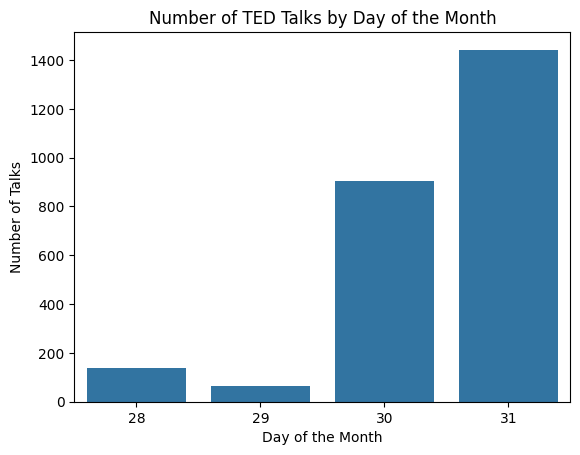

In [154]:
sns.barplot(x=talks_of_a_day.index, y=talks_of_a_day.values)
plt.xlabel('Day of the Month')
plt.ylabel('Number of Talks')
plt.title('Number of TED Talks by Day of the Month')

# Q4) What is the title of the most viewed talk in the event 'TED2017'?

In [172]:
# your code here
TED2017 = df[df['event'] == 'TED2017']

eventViews = TED2017[['title', 'views']]

eventViews = eventViews[eventViews['views'] == TED2017['views'].max()]['title'].values[0] #  عشان تظهر سترينج مش ليست   .values[0]



print(eventViews)

The future we're building -- and boring


# Q5) Who is the most popular speaker during the years from 2009 to 2016?

In [156]:
df.columns


Index(['comments', 'description', 'duration', 'event', 'film_date',
       'languages', 'main_speaker', 'name', 'num_speaker', 'published_date',
       'ratings', 'related_talks', 'speaker_occupation', 'tags', 'title',
       'url', 'views', 'event_date', 'day_of_week', 'day_of_month'],
      dtype='object')

In [178]:
df['years'] = df['event_date'].dt.year

speakerOverPeriod = df.loc[ (2009 <= df['years']) & (df['years'] <= 2016) , ['main_speaker'] ]

speakerOverPeriod['main_speaker'].mode()[0]


'Hans Rosling'